<a href="https://colab.research.google.com/github/joao-victor-g-dev/analise-ids-cicids2017/blob/main/Minera%C3%A7%C3%A3o_DataSet_CIC_IDS_2017_QUARTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MÓDULO 01: MONTAGEM DO DRIVE E EXTRAÇÃO

In [ ]:
# ==========================================
# MÓDULO 01: MONTAGEM DO DRIVE E EXTRAÇÃO
# ==========================================
from google.colab import drive
import os
import zipfile

# 1. Montar o Google Drive
drive.mount('/content/drive')

# 2. Caminhos do diretório
zip_path = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/CSV/MachineLearningCSV.zip'
extract_path = '/content/dataset_csv'

print("🔍 Verificando integridade dos dados locais...")

# 3. Verificação Inteligente: Checa se a pasta tem arquivos CSV dentro
precisa_extrair = True
if os.path.exists(extract_path):
    # Conta quantos arquivos .csv existem em toda a árvore da pasta
    csv_encontrados = sum(1 for _, _, files in os.walk(extract_path) for f in files if f.endswith('.csv'))
    if csv_encontrados > 0:
        precisa_extrair = False
        print(f"✅ Diretório íntegro! Foram encontrados {csv_encontrados} arquivos CSV. Extração pulada.")
    else:
        print("⚠️ A pasta existe, mas está VAZIA. Forçando nova extração...")

# 4. Extração (se necessária)
if precisa_extrair:
    os.makedirs(extract_path, exist_ok=True)
    print("⏳ Iniciando a extração do ZIP (isso pode levar de 1 a 3 minutos)...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Dataset extraído com sucesso para o armazenamento local!")
    except Exception as e:
        print(f"❌ Erro ao tentar extrair o arquivo: {e}")
        print("Verifique se o caminho do arquivo .zip está 100% correto.")

Mounted at /content/drive
🔍 Verificando integridade dos dados locais...
⏳ Iniciando a extração do ZIP (isso pode levar de 1 a 3 minutos)...
✅ Dataset extraído com sucesso para o armazenamento local!


# MÓDULO 02: ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

🔍 Buscando o arquivo da Quarta-feira (DoS)...
⏳ Carregando dados (Isso pode levar alguns segundos, o arquivo de Quarta é grande)...
✅ Dados carregados e limpos! Total de instâncias: 691406

🎨 Gerando Painel de Visualização Estatística...


/tmp/ipykernel_8905/1348676818.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label', palette='magma', ax=axes[0], edgecolor='black')
/tmp/ipykernel_8905/1348676818.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='Max Packet Length', palette='Set2', ax=axes[1])
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


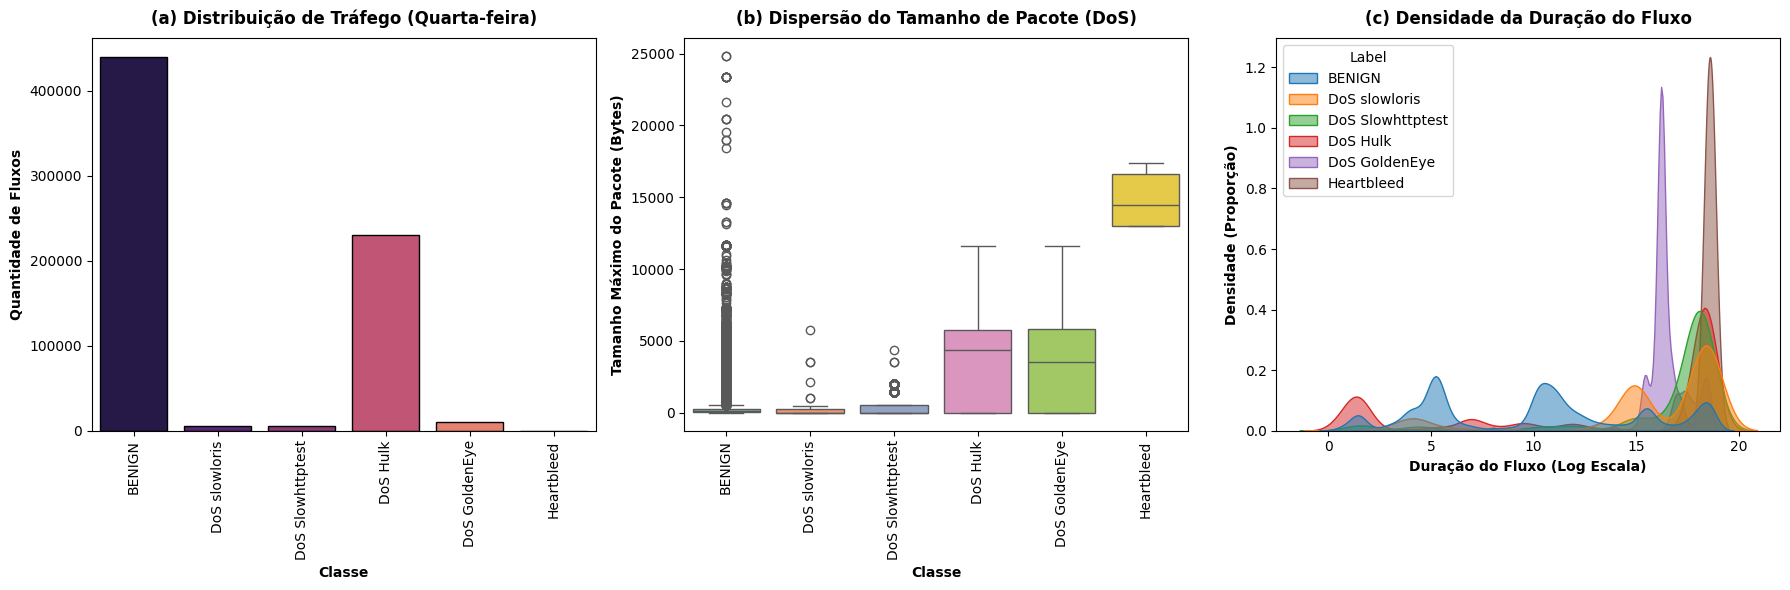

✅ Painel EDA exportado com sucesso para: /content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics/EDA/painel_eda_quarta.pdf


In [ ]:
# ==========================================
# MÓDULO 02 (QUARTA-FEIRA): ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# Foco: Ataques de Negação de Serviço (DoS / Heartbleed)
# ==========================================
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Parâmetros - Ajustados para Quarta-feira
ARQUIVO_ALVO = 'Wednesday-workingHours.pcap_ISCX.csv'
EXTRACT_PATH = '/content/dataset_csv'
DIRETORIO_GRAFICOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics/EDA'

os.makedirs(DIRETORIO_GRAFICOS, exist_ok=True)

# 2. Busca Inteligente do Arquivo
print("🔍 Buscando o arquivo da Quarta-feira (DoS)...")
CAMINHO_CSV = None
for root, dirs, files in os.walk(EXTRACT_PATH):
    if ARQUIVO_ALVO in files:
        CAMINHO_CSV = os.path.join(root, ARQUIVO_ALVO)
        break

if CAMINHO_CSV is None:
    raise FileNotFoundError(f"🚨 Arquivo {ARQUIVO_ALVO} não encontrado! Verifique a extração.")

# 3. Carregamento e Limpeza Básica
print("⏳ Carregando dados (Isso pode levar alguns segundos, o arquivo de Quarta é grande)...")
df = pd.read_csv(CAMINHO_CSV)
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"✅ Dados carregados e limpos! Total de instâncias: {len(df)}")

# ==========================================
# GERAÇÃO DO PAINEL VISUAL (IEEE FORMAT)
# ==========================================
print("\n🎨 Gerando Painel de Visualização Estatística...")
plt.rcParams['font.family'] = 'sans-serif'
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Gráfico 1: Distribuição de Classes (Bar Plot) ---
sns.countplot(data=df, x='Label', palette='magma', ax=axes[0], edgecolor='black')
axes[0].set_title('(a) Distribuição de Tráfego (Quarta-feira)', fontweight='bold', pad=10)
axes[0].set_ylabel('Quantidade de Fluxos', fontweight='bold')
axes[0].set_xlabel('Classe', fontweight='bold')
axes[0].tick_params(axis='x', rotation=90) # Rotação 90 graus porque a Quarta tem muitas classes (Hulk, GoldenEye, etc)

# --- Gráfico 2: Box Plot - Tamanho Máximo do Pacote ---
sns.boxplot(data=df, x='Label', y='Max Packet Length', palette='Set2', ax=axes[1])
axes[1].set_title('(b) Dispersão do Tamanho de Pacote (DoS)', fontweight='bold', pad=10)
axes[1].set_ylabel('Tamanho Máximo do Pacote (Bytes)', fontweight='bold')
axes[1].set_xlabel('Classe', fontweight='bold')
axes[1].tick_params(axis='x', rotation=90)

# --- Gráfico 3: Histograma (KDE) - Duração do Fluxo ---
df['Log_Flow_Duration'] = np.log1p(df['Flow Duration'])
sns.kdeplot(data=df, x='Log_Flow_Duration', hue='Label', fill=True, common_norm=False, palette='tab10', ax=axes[2], alpha=0.5)
axes[2].set_title('(c) Densidade da Duração do Fluxo', fontweight='bold', pad=10)
axes[2].set_ylabel('Densidade (Proporção)', fontweight='bold')
axes[2].set_xlabel('Duração do Fluxo (Log Escala)', fontweight='bold')

plt.tight_layout()

# Exportando para o Drive
caminho_painel = os.path.join(DIRETORIO_GRAFICOS, 'painel_eda_quarta.pdf')
plt.savefig(caminho_painel, bbox_inches='tight')
plt.show()

print(f"✅ Painel EDA exportado com sucesso para: {caminho_painel}")

# MÓDULO 03: PRÉ-PROCESSAMENTO (QUARTA-FEIRA - DoS)

In [ ]:
# ==========================================
# MÓDULO 03: PRÉ-PROCESSAMENTO (QUARTA-FEIRA - DoS)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import gc
import joblib
import os

NOME_EXPERIMENTO = 'Quarta_DoS'
DIRETORIO_ARTEFATOS = f'/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/{NOME_EXPERIMENTO}'
os.makedirs(DIRETORIO_ARTEFATOS, exist_ok=True)

print("1. Removendo colunas temporárias e isolando X e y...")
if 'Log_Flow_Duration' in df.columns:
    df = df.drop(columns=['Log_Flow_Duration'])

X = df.drop(columns=['Label'])
y = df['Label']

# Limpando a RAM do DataFrame original imediatamente (Crucial para a Quarta-feira que é pesada)
del df
gc.collect()

print("2. Codificando as Classes (Label Encoding)...")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
nomes_classes = label_encoder.classes_
print(f"   -> Classes mapeadas: {list(nomes_classes)}")
joblib.dump(label_encoder, os.path.join(DIRETORIO_ARTEFATOS, 'label_encoder.joblib'))

print("3. Dividindo em Treino (70%) e Teste (30%)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
del X, y
gc.collect()

print("4. Aplicando Normalização (StandardScaler)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(DIRETORIO_ARTEFATOS, 'scaler.joblib'))

# Limpando memória bruta
del X_train, X_test
gc.collect()

print("✅ Módulo 03 Concluído! Dados escalonados para a Quarta-feira.")

1. Removendo colunas temporárias e isolando X e y...
2. Codificando as Classes (Label Encoding)...
   -> Classes mapeadas: ['BENIGN', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'Heartbleed']
3. Dividindo em Treino (70%) e Teste (30%)...
4. Aplicando Normalização (StandardScaler)...
✅ Módulo 03 Concluído! Dados escalonados para a Quarta-feira.


# MÓDULO 04-A: TREINAMENTO RANDOM FOREST (QUARTA-FEIRA)

In [ ]:
# ==========================================
# MÓDULO 04-A: TREINAMENTO RANDOM FOREST (QUARTA-FEIRA)
# ==========================================
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

NOME_EXPERIMENTO = 'Quarta_DoS'
DIRETORIO_ARTEFATOS = f'/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/{NOME_EXPERIMENTO}'

print("🤖 Iniciando o Treinamento: Random Forest (Isso pode levar alguns minutos)...")

rf = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# Gerando predições e salvando
y_pred_rf = rf.predict(X_test_scaled)
joblib.dump(rf, os.path.join(DIRETORIO_ARTEFATOS, 'modelo_rf.joblib'))
joblib.dump(y_pred_rf, os.path.join(DIRETORIO_ARTEFATOS, 'y_pred_rf.joblib'))

print("✅ Random Forest treinado e salvo!")

🤖 Iniciando o Treinamento: Random Forest (Isso pode levar alguns minutos)...
✅ Random Forest treinado e salvo!


# MÓDULO 04-B: TREINAMENTO HIST GRADIENT BOOSTING (QUARTA-FEIRA)

In [ ]:
# ==========================================
# MÓDULO 04-B: TREINAMENTO HIST GRADIENT BOOSTING (QUARTA-FEIRA)
# ==========================================
from sklearn.ensemble import HistGradientBoostingClassifier
import joblib
import os

NOME_EXPERIMENTO = 'Quarta_DoS'
DIRETORIO_ARTEFATOS = f'/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/{NOME_EXPERIMENTO}'

print("🤖 Iniciando o Treinamento: HistGradientBoosting...")

hgb = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42)
hgb.fit(X_train_scaled, y_train)

# Gerando predições e salvando
y_pred_hgb = hgb.predict(X_test_scaled)
joblib.dump(hgb, os.path.join(DIRETORIO_ARTEFATOS, 'modelo_hgb.joblib'))
joblib.dump(y_pred_hgb, os.path.join(DIRETORIO_ARTEFATOS, 'y_pred_hgb.joblib'))

print("✅ HistGradientBoosting treinado e salvo!")

🤖 Iniciando o Treinamento: HistGradientBoosting...
✅ HistGradientBoosting treinado e salvo!


# MÓDULO 05: AVALIAÇÃO DE RESULTADOS E MATRIZES (QUARTA-FEIRA)

1. Carregando as predições e o Label Encoder do Drive...

📊 RELATÓRIO DE CLASSIFICAÇÃO METODOLÓGICA (QUARTA-FEIRA - DoS)

--- PERFORMANCE: RANDOM FOREST (BAGGING) ---
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    131905
   DoS GoldenEye       1.00      0.99      1.00      3088
        DoS Hulk       1.00      1.00      1.00     69037
DoS Slowhttptest       1.00      0.99      0.99      1650
   DoS slowloris       0.99      0.99      0.99      1739
      Heartbleed       1.00      1.00      1.00         3

        accuracy                           1.00    207422
       macro avg       1.00      1.00      1.00    207422
    weighted avg       1.00      1.00      1.00    207422


--- PERFORMANCE: HIST GRADIENT BOOSTING (BOOSTING) ---
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    131905
   DoS GoldenEye       0.99      0.99      0.99      3088
        DoS Hulk   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


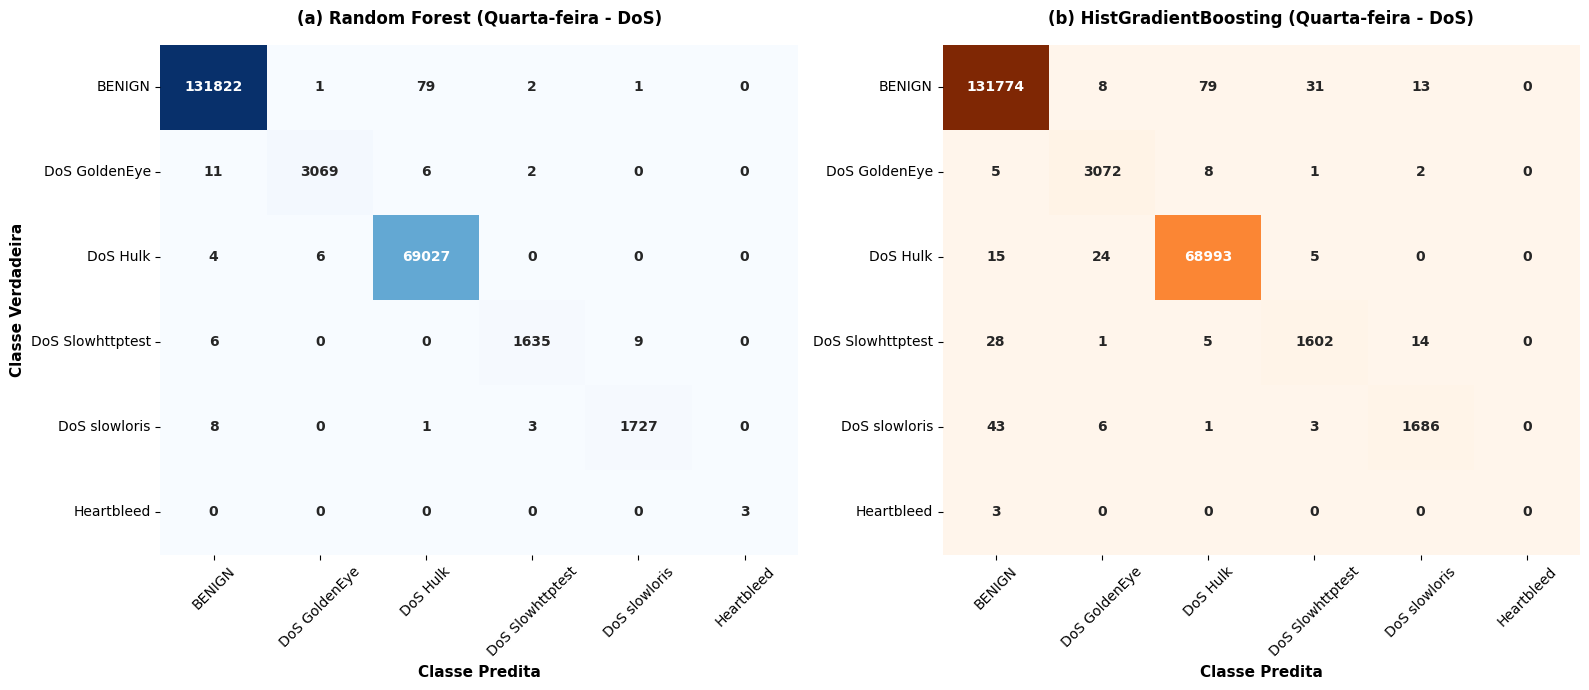

✅ Gráfico duplo exportado com sucesso para: /content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics/matrizes_confusao_Quarta_DoS.pdf


In [ ]:
# ==========================================
# MÓDULO 05: AVALIAÇÃO DE RESULTADOS E MATRIZES (QUARTA-FEIRA)
# ==========================================
import os
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuração de Caminhos
NOME_EXPERIMENTO = 'Quarta_DoS'
DIRETORIO_ARTEFATOS = f'/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/artifacts/{NOME_EXPERIMENTO}'
DIRETORIO_GRAFICOS = '/content/drive/MyDrive/Doutorado/Dataset-CIC-IDS-2017/graphics'
os.makedirs(DIRETORIO_GRAFICOS, exist_ok=True)

print("1. Carregando as predições e o Label Encoder do Drive...")
# Recuperando as classes salvas
label_encoder = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'label_encoder.joblib'))
nomes_classes = label_encoder.classes_

# Carregando as predições geradas nos módulos 04-A e 04-B
y_pred_rf = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'y_pred_rf.joblib'))
y_pred_hgb = joblib.load(os.path.join(DIRETORIO_ARTEFATOS, 'y_pred_hgb.joblib'))

print("\n" + "="*60)
print(f"📊 RELATÓRIO DE CLASSIFICAÇÃO METODOLÓGICA (QUARTA-FEIRA - DoS)")
print("="*60)
print("\n--- PERFORMANCE: RANDOM FOREST (BAGGING) ---")
print(classification_report(y_test, y_pred_rf, target_names=nomes_classes))

print("\n--- PERFORMANCE: HIST GRADIENT BOOSTING (BOOSTING) ---")
print(classification_report(y_test, y_pred_hgb, target_names=nomes_classes))

print("\n2. Renderizando painel de Matrizes de Confusão (IEEE)...")
plt.rcParams['font.family'] = 'sans-serif'
# Aumentei a largura da figura (16, 7) porque a quarta-feira tem mais classes para exibir
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Matriz 1: Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=nomes_classes, yticklabels=nomes_classes, annot_kws={"weight": "bold", "size": 10})
ax1.set_title('(a) Random Forest (Quarta-feira - DoS)', fontweight='bold', pad=15, fontsize=12)
ax1.set_ylabel('Classe Verdadeira', fontweight='bold', fontsize=11)
ax1.set_xlabel('Classe Predita', fontweight='bold', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

# Matriz 2: HistGradientBoosting
# Mudei a cor do HGB para Laranja/Vermelho para diferenciar da Terça-feira no seu artigo
cm_hgb = confusion_matrix(y_test, y_pred_hgb)
sns.heatmap(cm_hgb, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax2,
            xticklabels=nomes_classes, yticklabels=nomes_classes, annot_kws={"weight": "bold", "size": 10})
ax2.set_title('(b) HistGradientBoosting (Quarta-feira - DoS)', fontweight='bold', pad=15, fontsize=12)
ax2.set_ylabel('')
ax2.set_xlabel('Classe Predita', fontweight='bold', fontsize=11)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Salvando em PDF Vetorial
caminho_saida = os.path.join(DIRETORIO_GRAFICOS, f'matrizes_confusao_{NOME_EXPERIMENTO}.pdf')
plt.savefig(caminho_saida, bbox_inches='tight')
plt.show()

print(f"✅ Gráfico duplo exportado com sucesso para: {caminho_saida}")